In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data/processed/selected_features.csv')
df.head()

,session_recency_min,purchase_number_stddev,customer_value_month_lag0,purchase_recency_min,purchase_count_month_ma3,customer_value_month_ma3,purchase_number_sum,haspurchase_sum,session_count_month_lag0,purchase_number_max,...,session_recency_cv,session_recency_mean,purchase_recency_mean,purchase_count_sum,purchase_recency_max,time_step,session_recency_sum,start_year_sum,purchase_count_month_lag1,target_event
0,3.296586,7.359801,30.501347,10.381447,0.666667,31.98359,325,25,1,25,...,0.400700,93.046776,86.240555,26,148.34409,0,3721.870961,80773,1,0
1,12.257524,5.916080,0.000000,12.257524,0.666667,142.62169,210,20,0,20,...,0.434636,99.118000,100.179020,30,178.00300,0,5748.843796,117123,1,1
2,144.209300,6.782330,0.000000,144.209300,0.000000,0.00000,276,23,0,23,...,0.035127,155.845550,154.942000,40,161.49910,0,5454.594444,70665,0,1
3,0.443171,7.071068,344.579960,0.443171,5.500000,227.48508,300,24,7,24,...,1.493412,20.168068,17.992144,32,107.57222,0,584.873970,58577,12,0
4,49.352894,17.752934,0.000000,49.352894,0.000000,0.00000,1891,61,0,61,...,0.366169,123.920490,128.477250,64,179.55130,0,12020.287141,195874,0,1


In [3]:
X=df.drop(
    'target_event',
    axis=1
)
y=df['target_event']
print(X.shape)
print(y.shape)

(112610, 30)
(112610,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

In [5]:
print(X_train.shape)
print(X_test.shape)

(90088, 30)
(22522, 30)


---
### Logistic Regression:

In [6]:
lr=LogisticRegression(max_iter=1000)
lr.fit( X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
lr_pred=lr.predict(X_test)
lr_prob=lr.predict_proba(X_test)[:,1]

In [8]:
print("Accuracy :" ,accuracy_score(y_test, lr_pred))
print("Precision :" ,precision_score(y_test, lr_pred))
print("Recall :" ,recall_score(y_test, lr_pred))
print("F1 Score :" ,f1_score(y_test, lr_pred))
print("ROC AUC :" ,roc_auc_score(y_test, lr_prob))

Accuracy : 0.8012165882248469
Precision : 0.724848683134304
Recall : 0.6132023249377249
F1 Score : 0.6643676437514057
ROC AUC : 0.8139703394847986


---
### Random Forest:

In [9]:
rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [11]:
print("Accuracy :" ,accuracy_score(y_test, rf_pred))
print("Precision :" ,precision_score(y_test, rf_pred))
print("Recall :" ,recall_score(y_test, rf_pred))
print("F1 Score :" ,f1_score(y_test, rf_pred))
print("ROC AUC :" ,roc_auc_score(y_test, rf_prob))

Accuracy : 0.8596039428114732
Precision : 0.8367583692409678
Recall : 0.6987268198173263
F1 Score : 0.7615384615384615
ROC AUC : 0.9037296997881893


---
### XGBoost:

In [12]:
xgb=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [13]:
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [14]:
xgb_pred=xgb.predict(X_test)
xgb_prob=xgb.predict_proba(X_test)[:,1]

In [15]:
print("Accuracy :" ,accuracy_score(y_test, xgb_pred))
print("Precision :" ,precision_score(y_test, xgb_pred))
print("Recall :" ,recall_score(y_test, xgb_pred))
print("F1 Score :" ,f1_score(y_test, xgb_pred))
print("ROC AUC :" ,roc_auc_score(y_test, xgb_prob))

Accuracy : 0.8598703489920966
Precision : 0.8352553542009885
Recall : 0.7016329919734293
F1 Score : 0.7626353790613718
ROC AUC : 0.907534469538174


In [16]:
results=pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],

    'ROC AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]

})
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.801217,0.724849,0.613202,0.664368,0.813970
1,Random Forest,0.859604,0.836758,0.698727,0.761538,0.903730
2,XGBoost,0.859870,0.835255,0.701633,0.762635,0.907534


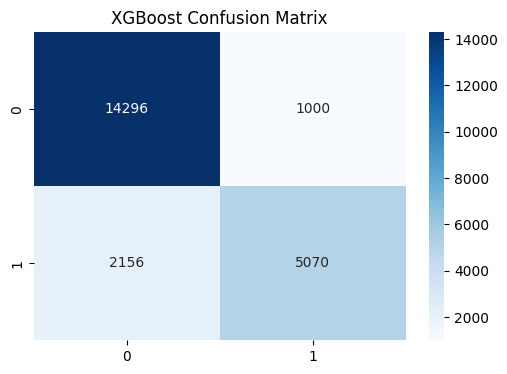

In [17]:
cm= confusion_matrix(y_test,xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('XGBoost Confusion Matrix')
plt.show()

In [18]:
with open('models/xgboost_model.pkl','wb') as file:
    pickle.dump(xgb,file)